# Day 4: 材料特征工程基础

今天的目标：

- 理解为什么机器学习模型不能直接使用 `TiO2`、`Al2O3` 这样的化学式字符串。
- 学会把化学式解析成元素及其数量。
- 手写几个最基础的组成特征。
- 保存带特征的数据表，为 Day 5 的带隙 baseline 做准备。

今天先不用 `pymatgen` 或 `matminer`，而是手写一个小型解析器和特征函数。这样可以先理解特征工程的本质。


In [1]:
import os
from pathlib import Path
import re

os.environ.setdefault("MPLCONFIGDIR", "../.matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
DOCS_DIR = PROJECT_ROOT / "docs"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: /mnt/d/桌面/ai—study/day03


## 1. 读取 Day 3 材料数据

今天继续使用 Day 3 的小型示例数据库。我们的重点不是数据量，而是把 `formula` 转成数值特征。

注意：真实数据库中有时会出现非标准名称或别名，比如 `Graphene`。传统化学式解析器更适合处理标准化学式，所以这里会先把 `Graphene` 规范化为 `C`。


In [2]:
df = pd.read_csv(RAW_DATA_DIR / "day3_demo_materials_database.csv")

# 真实数据清洗中，要先把材料名称规范成可解析的化学式。
df["formula"] = df["formula"].replace({"Graphene": "C"})

df[["material_id", "formula", "band_gap_eV", "material_family"]].head()


,material_id,formula,band_gap_eV,material_family
0,mp-demo-001,Si,1.12,element
1,mp-demo-002,Ge,0.67,element
2,mp-demo-003,GaAs,1.42,III-V
3,mp-demo-004,TiO2,3.20,oxide
4,mp-demo-005,ZnO,3.37,oxide


## 2. 为什么化学式需要特征工程

对人来说，`TiO2` 表示一个 Ti 和两个 O。你能根据材料知识判断它是氧化物。

但对大多数传统机器学习模型来说，`TiO2` 只是一个字符串，不能直接参与加减乘除。模型需要的是数值表格，例如：

```text
formula -> n_elements, total_atoms, contains_oxygen, mean_atomic_number, mean_electronegativity
```

这个过程就是特征工程。


## 3. 化学式解析函数

下面写一个简单函数，把 `TiO2` 解析成：

```python
{"Ti": 1, "O": 2}
```

注意：这个简单解析器只处理常见无括号化学式，不处理 `Ca(OH)2` 这种带括号的复杂情况。Day 4 的目标是理解流程，不追求解析器覆盖所有化学式。


In [3]:
def parse_formula(formula):
    """Parse a simple chemical formula into element counts.

    Examples
    --------
    TiO2 -> {"Ti": 1, "O": 2}
    Al2O3 -> {"Al": 2, "O": 3}
    """
    pattern = r"([A-Z][a-z]?)([0-9.]*)" # 正则表达式，()表示一组，？代表可选，*表示多个
    parts = re.findall(pattern, formula) # findall查找所有匹配项, 用pattern规则即()()两个一组生成一个二元元组的列表，拆分formula
    composition = {}
    for element, count_text in parts:
        count = float(count_text) if count_text else 1.0
        composition[element] = composition.get(element, 0.0) + count
    return composition

for formula in ["Si", "TiO2", "Al2O3", "BaTiO3", "MoS2"]:
    print(formula, "->", parse_formula(formula))


Si -> {'Si': 1.0}
TiO2 -> {'Ti': 1.0, 'O': 2.0}
Al2O3 -> {'Al': 2.0, 'O': 3.0}
BaTiO3 -> {'Ba': 1.0, 'Ti': 1.0, 'O': 3.0}
MoS2 -> {'Mo': 1.0, 'S': 2.0}


## 4. 准备一个小型元素属性表

真实项目可以使用 `pymatgen`、`matminer` 或元素数据库自动获取属性。今天为了入门，先手写本数据集中会遇到的元素属性。

这里使用几个直观属性：

- 原子序数 `Z`
- Pauling 电负性 `electronegativity`
- 原子质量 `atomic_mass`
- 是否为金属 `is_metal`
- 是否为过渡金属 `is_transition_metal`


In [4]:
element_props = {
    "Al": {"Z": 13, "electronegativity": 1.61, "atomic_mass": 26.98, "is_metal": 1, "is_transition_metal": 0},
    "As": {"Z": 33, "electronegativity": 2.18, "atomic_mass": 74.92, "is_metal": 0, "is_transition_metal": 0},
    "Ba": {"Z": 56, "electronegativity": 0.89, "atomic_mass": 137.33, "is_metal": 1, "is_transition_metal": 0},
    "C":  {"Z": 6,  "electronegativity": 2.55, "atomic_mass": 12.01, "is_metal": 0, "is_transition_metal": 0},
    "Cd": {"Z": 48, "electronegativity": 1.69, "atomic_mass": 112.41, "is_metal": 1, "is_transition_metal": 1},
    "Ce": {"Z": 58, "electronegativity": 1.12, "atomic_mass": 140.12, "is_metal": 1, "is_transition_metal": 0},
    "Cu": {"Z": 29, "electronegativity": 1.90, "atomic_mass": 63.55, "is_metal": 1, "is_transition_metal": 1},
    "Fe": {"Z": 26, "electronegativity": 1.83, "atomic_mass": 55.85, "is_metal": 1, "is_transition_metal": 1},
    "Ga": {"Z": 31, "electronegativity": 1.81, "atomic_mass": 69.72, "is_metal": 1, "is_transition_metal": 0},
    "Ge": {"Z": 32, "electronegativity": 2.01, "atomic_mass": 72.63, "is_metal": 0, "is_transition_metal": 0},
    "In": {"Z": 49, "electronegativity": 1.78, "atomic_mass": 114.82, "is_metal": 1, "is_transition_metal": 0},
    "Mo": {"Z": 42, "electronegativity": 2.16, "atomic_mass": 95.95, "is_metal": 1, "is_transition_metal": 1},
    "Ni": {"Z": 28, "electronegativity": 1.91, "atomic_mass": 58.69, "is_metal": 1, "is_transition_metal": 1},
    "O":  {"Z": 8,  "electronegativity": 3.44, "atomic_mass": 16.00, "is_metal": 0, "is_transition_metal": 0},
    "Pb": {"Z": 82, "electronegativity": 2.33, "atomic_mass": 207.20, "is_metal": 1, "is_transition_metal": 0},
    "S":  {"Z": 16, "electronegativity": 2.58, "atomic_mass": 32.06, "is_metal": 0, "is_transition_metal": 0},
    "Si": {"Z": 14, "electronegativity": 1.90, "atomic_mass": 28.09, "is_metal": 0, "is_transition_metal": 0},
    "Sn": {"Z": 50, "electronegativity": 1.96, "atomic_mass": 118.71, "is_metal": 1, "is_transition_metal": 0},
    "Sr": {"Z": 38, "electronegativity": 0.95, "atomic_mass": 87.62, "is_metal": 1, "is_transition_metal": 0},
    "Ti": {"Z": 22, "electronegativity": 1.54, "atomic_mass": 47.87, "is_metal": 1, "is_transition_metal": 1},
    "W":  {"Z": 74, "electronegativity": 2.36, "atomic_mass": 183.84, "is_metal": 1, "is_transition_metal": 1},
    "Zn": {"Z": 30, "electronegativity": 1.65, "atomic_mass": 65.38, "is_metal": 1, "is_transition_metal": 1},
}


## 5. 从化学式构造组成特征

下面的函数会输出几个基础特征：

- `n_elements`：元素种类数。
- `total_atoms`：化学式中的原子总数。
- `contains_oxygen`：是否含氧。
- `contains_transition_metal`：是否含过渡金属。
- `metal_fraction`：金属元素原子占比。
- `mean_atomic_number`：按原子数加权平均原子序数。
- `mean_electronegativity`：按原子数加权平均电负性。
- `mean_atomic_mass`：按原子数加权平均原子质量。
- `max_electronegativity_diff`：元素间最大电负性差。


In [5]:
def featurize_formula(formula):
    composition = parse_formula(formula)
    total_atoms = sum(composition.values())
    elements = list(composition.keys())

    weighted_Z = 0.0
    weighted_en = 0.0
    weighted_mass = 0.0
    metal_atoms = 0.0
    contains_transition_metal = 0
    electronegativities = []

    for element, count in composition.items():
        if element not in element_props:
            raise KeyError(f"Missing element properties for {element} in formula {formula}")
        props = element_props[element]
        fraction = count / total_atoms
        weighted_Z += fraction * props["Z"]
        weighted_en += fraction * props["electronegativity"]
        weighted_mass += fraction * props["atomic_mass"]
        metal_atoms += count * props["is_metal"]
        contains_transition_metal = max(contains_transition_metal, props["is_transition_metal"])
        electronegativities.append(props["electronegativity"])

    return {
        "n_elements_featurized": len(elements),
        "total_atoms": total_atoms,
        "contains_oxygen_featurized": int("O" in composition),
        "contains_transition_metal": contains_transition_metal,
        "metal_fraction": metal_atoms / total_atoms,
        "mean_atomic_number": weighted_Z,
        "mean_electronegativity": weighted_en,
        "mean_atomic_mass": weighted_mass,
        "max_electronegativity_diff": max(electronegativities) - min(electronegativities),
    }

featurize_formula("TiO2")


{'n_elements_featurized': 2,
 'total_atoms': 3.0,
 'contains_oxygen_featurized': 1,
 'contains_transition_metal': 1,
 'metal_fraction': 0.3333333333333333,
 'mean_atomic_number': 12.666666666666666,
 'mean_electronegativity': 2.806666666666666,
 'mean_atomic_mass': 26.62333333333333,
 'max_electronegativity_diff': 1.9}

In [6]:
feature_df = pd.DataFrame([featurize_formula(formula) for formula in df["formula"]])
feature_df.head()


,n_elements_featurized,total_atoms,contains_oxygen_featurized,contains_transition_metal,metal_fraction,mean_atomic_number,mean_electronegativity,mean_atomic_mass,max_electronegativity_diff
0,1,1.0,0,0,0.000000,14.000000,1.900000,28.090000,0.00
1,1,1.0,0,0,0.000000,32.000000,2.010000,72.630000,0.00
2,2,2.0,0,0,0.500000,32.000000,1.995000,72.320000,0.37
3,2,3.0,1,1,0.333333,12.666667,2.806667,26.623333,1.90
4,2,2.0,1,1,0.500000,19.000000,2.545000,40.690000,1.79


In [7]:
materials_with_features = pd.concat([df, feature_df], axis=1)
materials_with_features.head()


,material_id,formula,band_gap_eV,formation_energy_eV_atom,e_above_hull_eV_atom,crystal_system,material_family,n_elements_featurized,total_atoms,contains_oxygen_featurized,contains_transition_metal,metal_fraction,mean_atomic_number,mean_electronegativity,mean_atomic_mass,max_electronegativity_diff
0,mp-demo-001,Si,1.12,0.00,0.00,cubic,element,1,1.0,0,0,0.000000,14.000000,1.900000,28.090000,0.00
1,mp-demo-002,Ge,0.67,0.00,0.01,cubic,element,1,1.0,0,0,0.000000,32.000000,2.010000,72.630000,0.00
2,mp-demo-003,GaAs,1.42,-0.35,0.02,cubic,III-V,2,2.0,0,0,0.500000,32.000000,1.995000,72.320000,0.37
3,mp-demo-004,TiO2,3.20,-3.05,0.00,tetragonal,oxide,2,3.0,1,1,0.333333,12.666667,2.806667,26.623333,1.90
4,mp-demo-005,ZnO,3.37,-1.75,0.01,hexagonal,oxide,2,2.0,1,1,0.500000,19.000000,2.545000,40.690000,1.79


## 6. 保存带特征的数据

这是 Day 5 训练 baseline 的输入数据。模型会用这些数值特征预测 `band_gap_eV`。


In [8]:
feature_path = PROCESSED_DATA_DIR / "day4_materials_with_features.csv"
materials_with_features.to_csv(feature_path, index=False)
feature_path


PosixPath('/mnt/d/桌面/ai—study/day03/data/processed/day4_materials_with_features.csv')

## 7. 看特征和带隙的关系

现在我们画两个散点图，直观看看某些特征是否和带隙有关。

注意：样本很少，图只能帮助理解，不能作为规律证明。


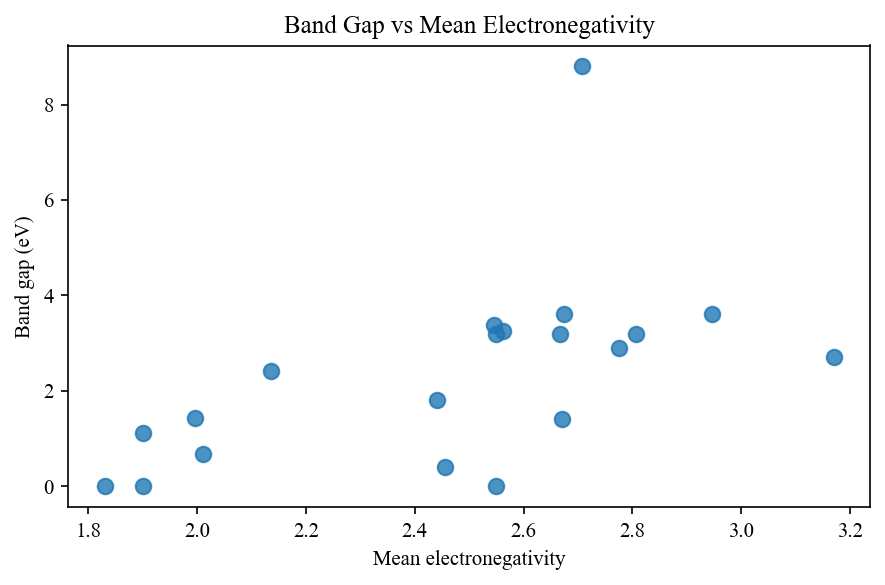

In [9]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.scatter(materials_with_features["mean_electronegativity"], materials_with_features["band_gap_eV"], s=55, alpha=0.8)
ax.set_xlabel("Mean electronegativity")
ax.set_ylabel("Band gap (eV)")
ax.set_title("Band Gap vs Mean Electronegativity")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "day4_gap_vs_mean_electronegativity.png", dpi=300)
plt.show()


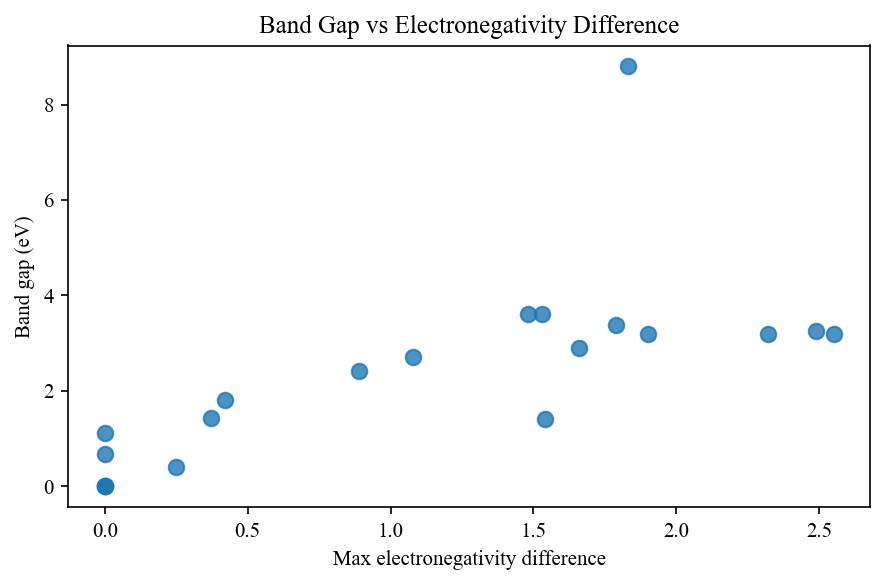

In [10]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.scatter(materials_with_features["max_electronegativity_diff"], materials_with_features["band_gap_eV"], s=55, alpha=0.8)
ax.set_xlabel("Max electronegativity difference")
ax.set_ylabel("Band gap (eV)")
ax.set_title("Band Gap vs Electronegativity Difference")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "day4_gap_vs_en_diff.png", dpi=300)
plt.show()


## 8. 相关性初步查看

相关性不是因果关系，但可以帮助你快速发现哪些数值特征和目标可能有关。


In [14]:
feature_cols = [
    "n_elements_featurized",
    "total_atoms",
    "contains_oxygen_featurized",
    "contains_transition_metal",
    "metal_fraction",
    "mean_atomic_number",
    "mean_electronegativity",
    "mean_atomic_mass",
    "max_electronegativity_diff",
]
# 计算所有特征与 band_gap_eV 的相关系数并排序，用于快速找出哪些特征对带隙预测最重要。
corr_with_gap = materials_with_features[feature_cols + ["band_gap_eV"]].corr(numeric_only=True)["band_gap_eV"].sort_values(ascending=False)

corr_with_gap


band_gap_eV                   1.000000
total_atoms                   0.707756
max_electronegativity_diff    0.696980
contains_oxygen_featurized    0.688129
mean_electronegativity        0.546797
n_elements_featurized         0.525351
contains_transition_metal    -0.048351
metal_fraction               -0.108542
mean_atomic_mass             -0.393600
mean_atomic_number           -0.413218
Name: band_gap_eV, dtype: float64

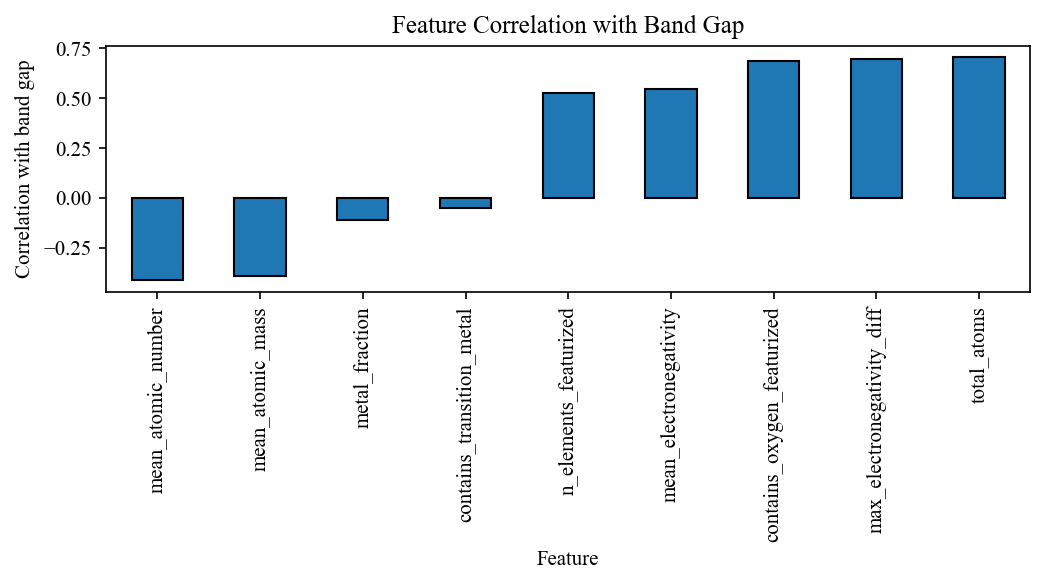

In [12]:
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
corr_with_gap.drop("band_gap_eV").sort_values().plot(kind="bar", ax=ax, edgecolor="black")
ax.set_xlabel("Feature")
ax.set_ylabel("Correlation with band gap")
ax.set_title("Feature Correlation with Band Gap")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "day4_feature_correlation_with_gap.png", dpi=300)
plt.show()


## 9. 今日练习

请你完成下面几个练习：

1. 用 `parse_formula` 解析 `BaTiO3`、`WO3`、`CdS`，确认结果是否符合化学式。
2. 新增一个特征 `oxygen_fraction`：氧原子数 / 总原子数。
3. 新增一个特征 `avg_atoms_per_element`：总原子数 / 元素种类数。
4. 保存更新后的特征表到 `data/processed/day4_materials_with_extra_features.csv`。
5. 写一段简短解释：为什么 `formula` 不能直接作为 `LinearRegression` 的输入？


In [17]:
# 练习 1：解析 BaTiO3、WO3、CdS
for formula in ["BaTiO3", "WO3", "CdS"]:
    print(formula, "->", parse_formula(formula))

BaTiO3 -> {'Ba': 1.0, 'Ti': 1.0, 'O': 3.0}
WO3 -> {'W': 1.0, 'O': 3.0}
CdS -> {'Cd': 1.0, 'S': 1.0}


In [23]:
# 练习 2：新增 oxygen_fraction 特征
def featurize_formula(formula):
    composition = parse_formula(formula)
    total_atoms = sum(composition.values())
    elements = list(composition.keys())

    weighted_Z = 0.0
    weighted_en = 0.0
    weighted_mass = 0.0
    metal_atoms = 0.0
    contains_transition_metal = 0
    electronegativities = []

    for element, count in composition.items():
        if element not in element_props:
            raise KeyError(f"Missing element properties for {element} in formula {formula}")
        props = element_props[element]
        fraction = count / total_atoms
        weighted_Z += fraction * props["Z"]
        weighted_en += fraction * props["electronegativity"]
        weighted_mass += fraction * props["atomic_mass"]
        metal_atoms += count * props["is_metal"]
        contains_transition_metal = max(contains_transition_metal, props["is_transition_metal"])
        electronegativities.append(props["electronegativity"])
        oxygen_fraction = composition.get("O", 0.0) / total_atoms

    return {
        "n_elements_featurized": len(elements),
        "total_atoms": total_atoms,
        "contains_oxygen_featurized": int("O" in composition),
        "contains_transition_metal": contains_transition_metal,
        "metal_fraction": metal_atoms / total_atoms,
        "mean_atomic_number": weighted_Z,
        "mean_electronegativity": weighted_en,
        "mean_atomic_mass": weighted_mass,
        "max_electronegativity_diff": max(electronegativities) - min(electronegativities),
        "oxygen_fraction": oxygen_fraction
    }

featurize_formula("BaTiO3")

{'n_elements_featurized': 3,
 'total_atoms': 5.0,
 'contains_oxygen_featurized': 1,
 'contains_transition_metal': 1,
 'metal_fraction': 0.4,
 'mean_atomic_number': 20.400000000000002,
 'mean_electronegativity': 2.5500000000000003,
 'mean_atomic_mass': 46.64000000000001,
 'max_electronegativity_diff': 2.55,
 'oxygen_fraction': 0.6}

In [27]:
# 练习 3：新增 avg_atoms_per_element 特征
def featurize_formula(formula):
    composition = parse_formula(formula)
    total_atoms = sum(composition.values())
    elements = list(composition.keys())

    weighted_Z = 0.0
    weighted_en = 0.0
    weighted_mass = 0.0
    metal_atoms = 0.0
    contains_transition_metal = 0
    electronegativities = []

    for element, count in composition.items():
        if element not in element_props:
            raise KeyError(f"Missing element properties for {element} in formula {formula}")
        props = element_props[element]
        fraction = count / total_atoms
        weighted_Z += fraction * props["Z"]
        weighted_en += fraction * props["electronegativity"]
        weighted_mass += fraction * props["atomic_mass"]
        metal_atoms += count * props["is_metal"]
        contains_transition_metal = max(contains_transition_metal, props["is_transition_metal"])
        electronegativities.append(props["electronegativity"])
        oxygen_fraction = composition.get("O", 0.0) / total_atoms
        
    return {
        "n_elements_featurized": len(elements),
        "total_atoms": total_atoms,
        "contains_oxygen_featurized": int("O" in composition),
        "contains_transition_metal": contains_transition_metal,
        "metal_fraction": metal_atoms / total_atoms,
        "mean_atomic_number": weighted_Z,
        "mean_electronegativity": weighted_en,
        "mean_atomic_mass": weighted_mass,
        "max_electronegativity_diff": max(electronegativities) - min(electronegativities),
        "oxygen_fraction": oxygen_fraction,
        "avg_atoms_per_element": total_atoms / len(elements)
    }

featurize_formula("BaTiO3")

{'n_elements_featurized': 3,
 'total_atoms': 5.0,
 'contains_oxygen_featurized': 1,
 'contains_transition_metal': 1,
 'metal_fraction': 0.4,
 'mean_atomic_number': 20.400000000000002,
 'mean_electronegativity': 2.5500000000000003,
 'mean_atomic_mass': 46.64000000000001,
 'max_electronegativity_diff': 2.55,
 'oxygen_fraction': 0.6,
 'avg_atoms_per_element': 1.6666666666666667}

In [28]:
# 练习 4：保存更新后的特征表
feature_df = pd.DataFrame([featurize_formula(formula) for formula in df["formula"]])
materials_with_features = pd.concat([df, feature_df], axis=1)
materials_with_features.to_csv(PROCESSED_DATA_DIR / "day4_materials_with_extra_features.csv", index=False)
materials_with_features.head()

,material_id,formula,band_gap_eV,formation_energy_eV_atom,e_above_hull_eV_atom,crystal_system,material_family,n_elements_featurized,total_atoms,contains_oxygen_featurized,contains_transition_metal,metal_fraction,mean_atomic_number,mean_electronegativity,mean_atomic_mass,max_electronegativity_diff,oxygen_fraction,avg_atoms_per_element
0,mp-demo-001,Si,1.12,0.00,0.00,cubic,element,1,1.0,0,0,0.000000,14.000000,1.900000,28.090000,0.00,0.000000,1.0
1,mp-demo-002,Ge,0.67,0.00,0.01,cubic,element,1,1.0,0,0,0.000000,32.000000,2.010000,72.630000,0.00,0.000000,1.0
2,mp-demo-003,GaAs,1.42,-0.35,0.02,cubic,III-V,2,2.0,0,0,0.500000,32.000000,1.995000,72.320000,0.37,0.000000,1.0
3,mp-demo-004,TiO2,3.20,-3.05,0.00,tetragonal,oxide,2,3.0,1,1,0.333333,12.666667,2.806667,26.623333,1.90,0.666667,1.5
4,mp-demo-005,ZnO,3.37,-1.75,0.01,hexagonal,oxide,2,2.0,1,1,0.500000,19.000000,2.545000,40.690000,1.79,0.500000,1.0


In [ ]:
# 练习 5：解释为什么 formula 不能直接作为 LinearRegression 的输入
 # LinearRegression 只能接收数值矩阵作为输入，不能直接理解 "TiO2" 这种字符串。
 # 化学式需要先转换成数值特征，例如元素种类数、总原子数、平均电负性、平均原子序数等。

## 10. 今日自查

完成 Day 4 后，请确认你能回答：

- 为什么 `TiO2` 这样的字符串不能直接输入传统机器学习模型？
- `parse_formula("Al2O3")` 应该得到什么结果？
- `n_elements` 和 `total_atoms` 有什么区别？
- 什么是按原子数加权平均？
- 为什么电负性可能和带隙有关？
- 手写特征和 `matminer` 特征有什么区别？
- 如果要预测吸附能，只用组成特征够不够？为什么？
  1. TiO2 不能直接输入传统机器学习模型，因为它是字符串；线性回归、随机森林等模型需要数值矩阵。
  2. parse_formula("Al2O3") 应得到 {"Al": 2, "O": 3}。
  3. n_elements 是元素种类数，total_atoms 是化学式中的原子总数。例如 Al2O3 的 n_elements=2，
     total_atoms=5。

  4. 按原子数加权平均就是按元素在化学式中的比例求平均。例如 TiO2 中 O 占 2/3，Ti 占 1/3。
  5. 电负性和成键离子性、电子局域程度有关，因此可能和带隙大小有关。
  6. 手写特征少、直观、适合入门；matminer 特征更多、更系统，适合正式项目。
  7. 预测吸附能时，只用组成特征通常不够，因为吸附能还强烈依赖表面结构、吸附位点、气体分子、键长、电荷转
     移等信息。
